# Khisto Demo

A good histogram should reveal structure without asking you to guess the right bin count first.

This notebook starts with a deliberately awkward distribution: a sharp spike, a broad shoulder, a long right tail, and a few isolated values. It is the kind of data where fixed-width bins often hide the story, while Khisto stays readable with one call.

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Build a deliberately hard distribution: one narrow spike, one broad shoulder,
# one long right tail, and a few isolated values.
rng = np.random.default_rng(42)
data = np.concatenate(
    [
        rng.normal(-2.6, 0.18, 420),
        rng.normal(0.4, 1.05, 520),
        rng.lognormal(mean=1.0, sigma=0.55, size=180) + 1.2,
        np.array([8.5, 9.0, 9.8, 10.5]),
    ]
)

print(f"Samples: {data.shape[0]}")
print(f"Range: [{data.min():.2f}, {data.max():.2f}]")
print("Story: a sharp left spike, a wide middle mass, and a stretched right tail.")

Samples: 1124
Range: [-3.06, 13.94]
Story: a sharp left spike, a wide middle mass, and a stretched right tail.


## 1. NumPy-like API: `khisto.histogram`

Start with the simplest promise: keep the familiar NumPy return value, but let the bins adapt to the data instead of flattening it.

In [17]:
from khisto import histogram

# Compute optimal histogram
hist, bin_edges = histogram(data)

print(f"Number of bins: {len(hist)}")
print(f"Bin edges: {bin_edges}")
print(f"Frequencies: {hist}")

Number of bins: 11
Bin edges: [-3.0625 -2.875  -2.6875 -2.4375 -2.25   -0.8125  0.      0.875   1.9375
  5.0625  7.375  14.    ]
Frequencies: [ 23. 101. 233.  57.  73. 117. 187. 117. 168.  38.  10.]


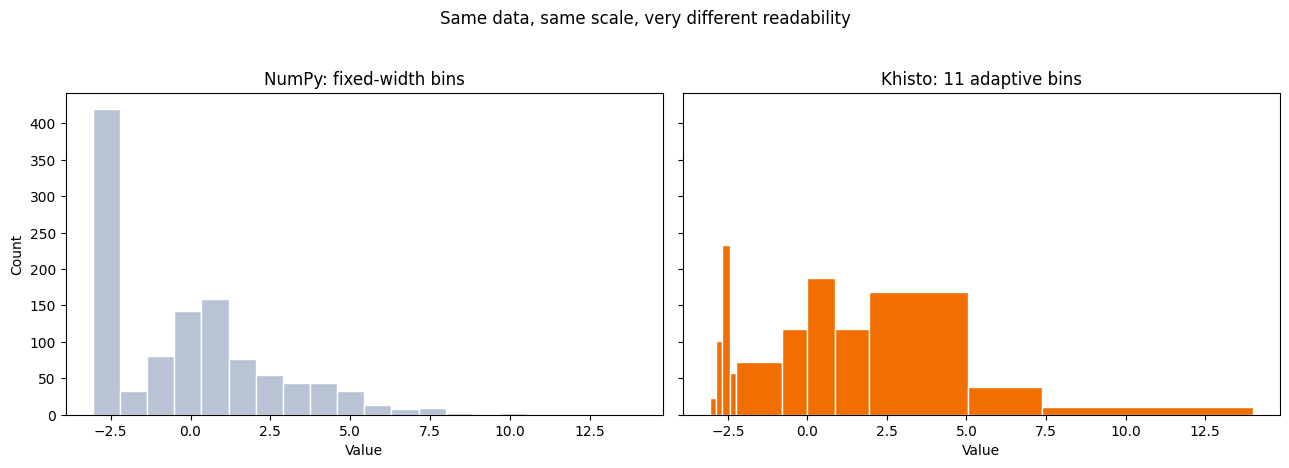

In [18]:
# Compare fixed-width bins with Khisto using a simple bar plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

# NumPy histogram (fixed bins)
np_hist, np_edges = np.histogram(data, bins=20)
axes[0].bar(
    np_edges[:-1],
    np_hist,
    width=np.diff(np_edges),
    align="edge",
    color="#B8C4D6",
    edgecolor="white",
)
axes[0].set_title("NumPy: fixed-width bins")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")

# Khisto histogram (adaptive bins)
axes[1].bar(
    bin_edges[:-1],
    hist,
    width=np.diff(bin_edges),
    align="edge",
    color="#F16E00",
    edgecolor="white",
)
axes[1].set_title(f"Khisto: {len(hist)} adaptive bins")
axes[1].set_xlabel("Value")

fig.suptitle("Same data, same scale, very different readability", y=1.03)
plt.tight_layout()
plt.show()

In [19]:
# With density normalization
density, bin_edges = histogram(data, density=True)

# Verify normalization (integral should be ~1)
widths = np.diff(bin_edges)
integral = np.sum(density * widths)
print(f"Integral of density: {integral:.6f}")

Integral of density: 1.000000


In [20]:
# With max_bins limit
hist_limited, edges_limited = histogram(data, max_bins=5)
print(f"Limited to max 5 bins: got {len(hist_limited)} bins")
print(f"Bin edges: {edges_limited}")

Limited to max 5 bins: got 4 bins
Bin edges: [-3.0625  0.      4.      8.     14.    ]


In [21]:
# With range specification
hist_range, edges_range = histogram(data, range=(-3, 3))
print(f"Range [-3, 3]: {len(hist_range)} bins")
print(f"Bin edges: {edges_range}")

Range [-3, 3]: 9 bins
Bin edges: [-3.     -2.875  -2.6875 -2.4375 -2.25   -0.8125  0.      0.875   1.625
  3.    ]


## 2. Matplotlib API: `khisto.matplotlib.hist`

Once the bins are right, plotting should stay effortless. `khisto.matplotlib.hist` keeps the familiar matplotlib workflow and makes the hard distribution readable in one line.

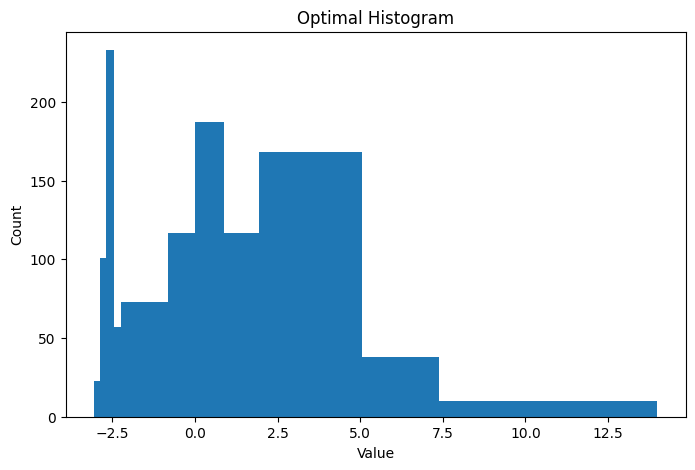

Returned 11 bin values


In [22]:
from khisto.matplotlib import hist

# Basic histogram plot
fig, ax = plt.subplots(figsize=(8, 5))
n, bins, patches = hist(data, ax=ax)
ax.set_xlabel("Value")
ax.set_ylabel("Count")
ax.set_title("Optimal Histogram")
plt.show()

print(f"Returned {len(n)} bin values")

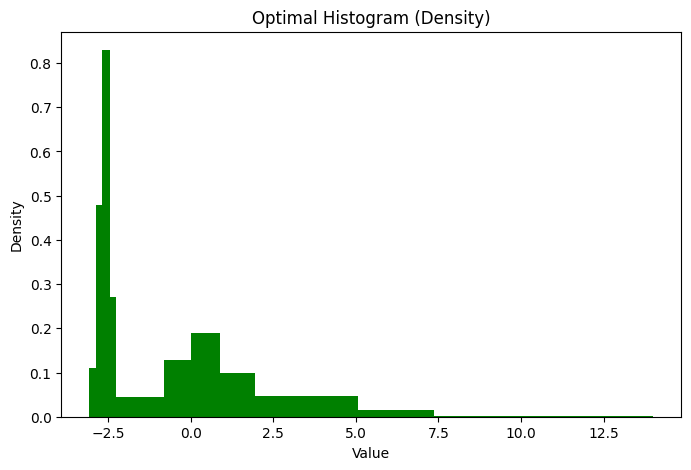

In [23]:
# Density plot
fig, ax = plt.subplots(figsize=(8, 5))
n, bins, patches = hist(data, density=True, ax=ax, color="green")
ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax.set_title("Optimal Histogram (Density)")
plt.show()

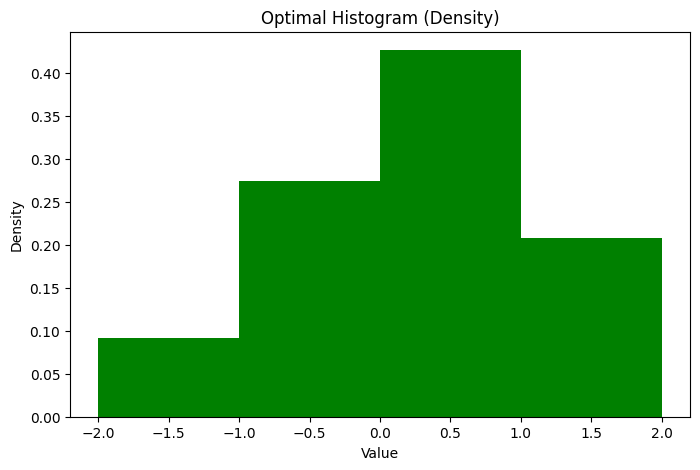

In [24]:
# Density plot
fig, ax = plt.subplots(figsize=(8, 5))
n, bins, patches = hist(data, density=True, range=(-2, 2), ax=ax, color="green")
ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax.set_title("Optimal Histogram (Density)")
plt.show()

### Cumulative plots with `khisto.matplotlib.hist`

`khisto.matplotlib.hist` supports matplotlib-style cumulative plots, including reverse cumulative counts and cumulative probabilities.

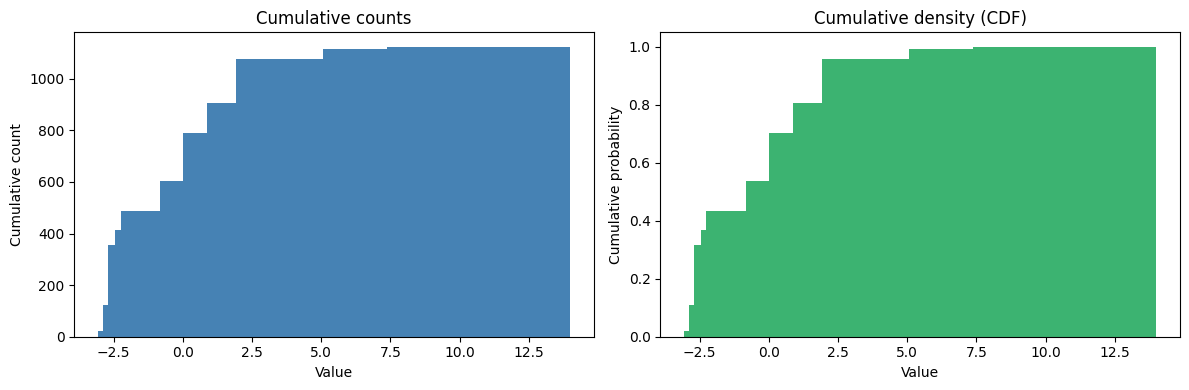

Last cumulative count: 1124
Last cumulative probability: 1.000000


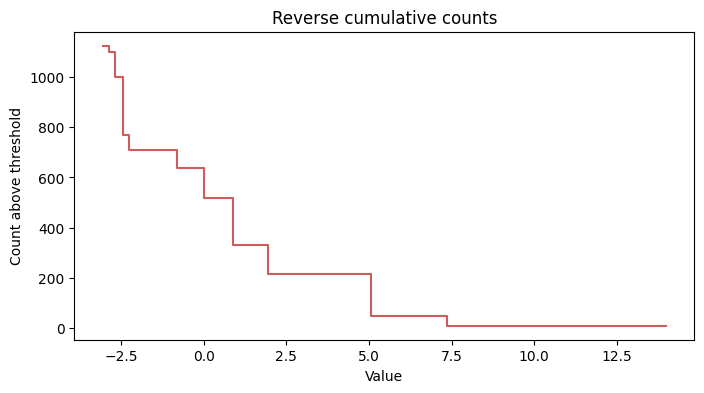

First reverse cumulative count: 1124


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cum_n, cum_bins, _ = hist(data, cumulative=True, ax=axes[0], color="steelblue")
axes[0].set_title("Cumulative counts")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Cumulative count")

cdf_n, cdf_bins, _ = hist(
    data,
    density=True,
    cumulative=True,
    ax=axes[1],
    color="mediumseagreen",
)
axes[1].set_title("Cumulative density (CDF)")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Cumulative probability")
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print(f"Last cumulative count: {cum_n[-1]:.0f}")
print(f"Last cumulative probability: {cdf_n[-1]:.6f}")

fig, ax = plt.subplots(figsize=(8, 4))
reverse_n, reverse_bins, _ = hist(
    data,
    cumulative=-1,
    ax=ax,
    color="indianred",
    histtype="step",
)
ax.set_title("Reverse cumulative counts")
ax.set_xlabel("Value")
ax.set_ylabel("Count above threshold")
plt.show()

print(f"First reverse cumulative count: {reverse_n[0]:.0f}")

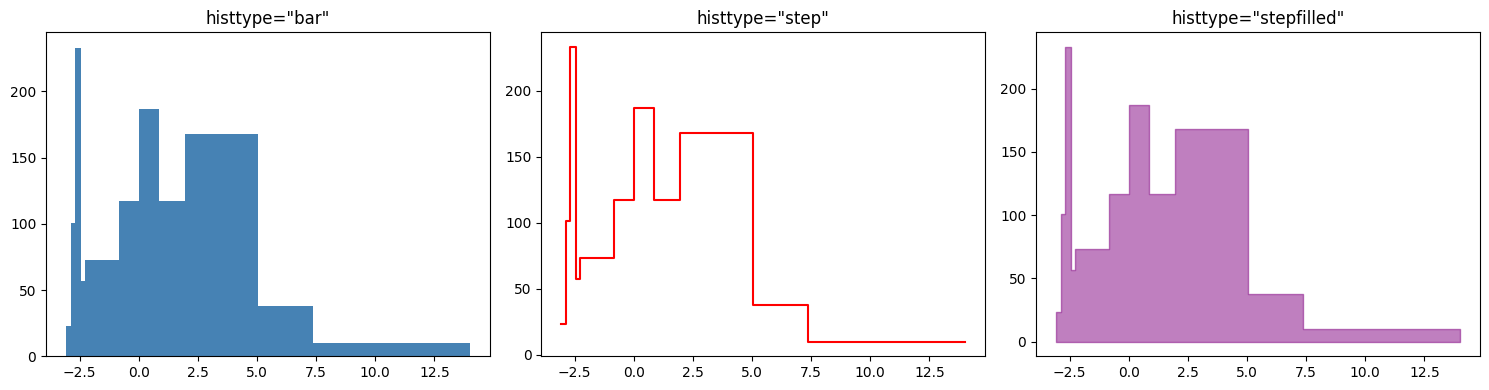

In [26]:
# Different histogram types
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

hist(data, histtype="bar", ax=axes[0], color="steelblue")
axes[0].set_title('histtype="bar"')

hist(data, histtype="step", ax=axes[1], color="red")
axes[1].set_title('histtype="step"')

hist(data, histtype="stepfilled", ax=axes[2], color="purple", alpha=0.5)
axes[2].set_title('histtype="stepfilled"')

plt.tight_layout()
plt.show()

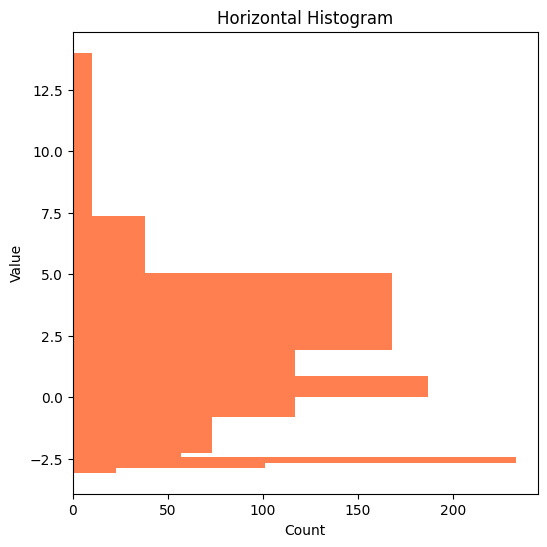

In [27]:
# Horizontal orientation
fig, ax = plt.subplots(figsize=(6, 6))
hist(data, orientation="horizontal", ax=ax, color="coral")
ax.set_xlabel("Count")
ax.set_ylabel("Value")
ax.set_title("Horizontal Histogram")
plt.show()

## 3. Core API: `compute_histograms` and `HistogramResult`

When one adaptive histogram is not enough, the core API lets you inspect the full sequence of granularities and see exactly where Khisto chooses to stop.

In [28]:
from khisto.core import compute_histograms

# Get all granularity levels
results = compute_histograms(data)

print(f"Number of granularity levels: {len(results)}")
print("\nGranularity levels:")
for result in results:
    marker = " <- BEST" if result.is_best else ""
    print(
        f"  Granularity {result.granularity}: {len(result.frequencies)} bins{marker}"
    )

Number of granularity levels: 10

Granularity levels:
  Granularity 0: 1 bins
  Granularity 1: 2 bins
  Granularity 2: 3 bins
  Granularity 3: 4 bins
  Granularity 4: 7 bins
  Granularity 5: 9 bins
  Granularity 6: 10 bins
  Granularity 7: 11 bins
  Granularity 8: 12 bins
  Granularity 9: 11 bins <- BEST


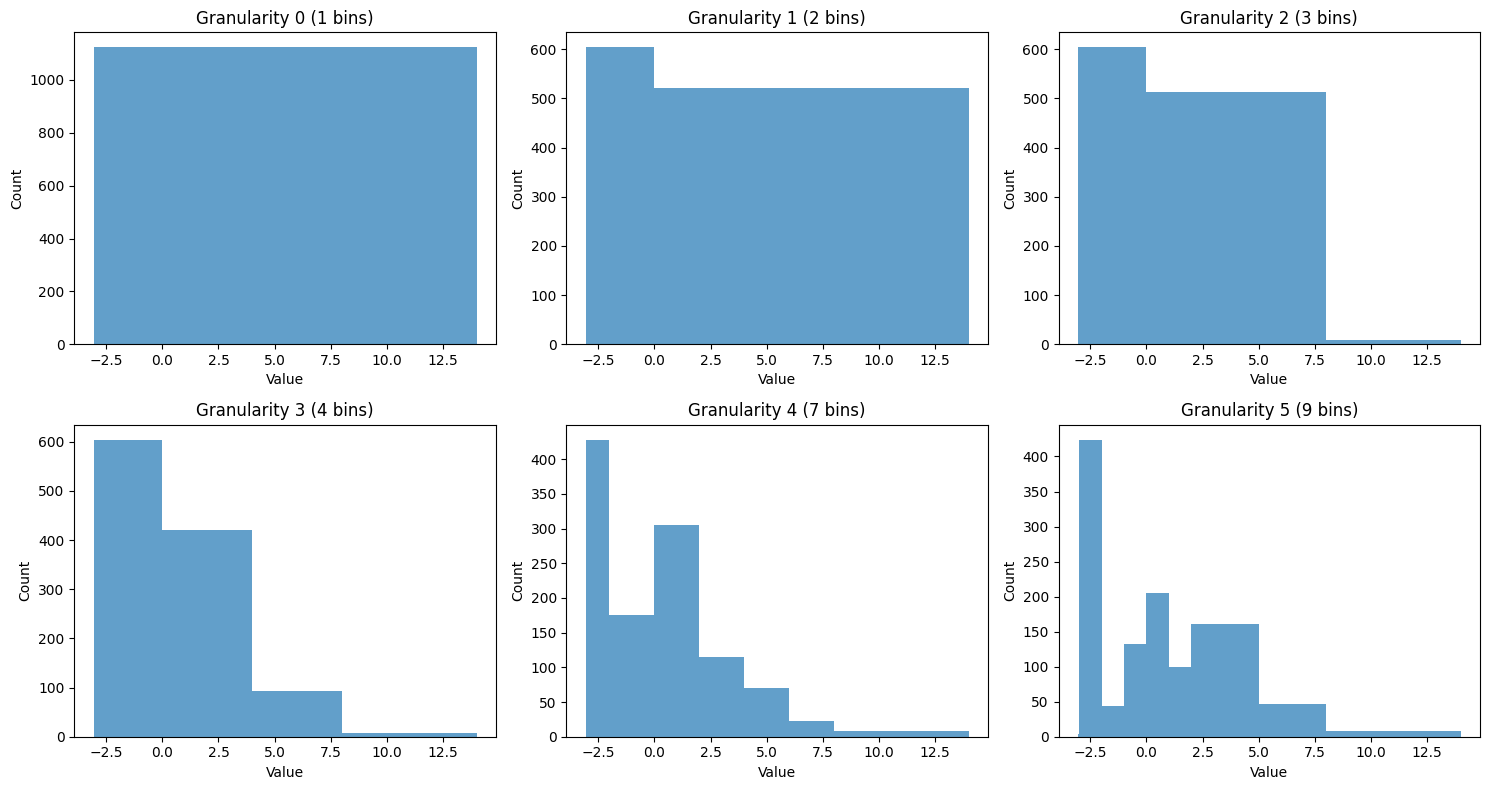

In [29]:
# Visualize different granularities
n_levels = min(6, len(results))
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, result in enumerate(results[:n_levels]):
    ax = axes[i]
    ax.stairs(result.frequencies, result.bin_edges, fill=True, alpha=0.7)
    title = f"Granularity {result.granularity} ({len(result.frequencies)} bins)"
    if result.is_best:
        title += " * BEST"
        ax.set_facecolor("#ffffee")
    ax.set_title(title)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## Summary

Khisto gives you a better histogram without making you tune bins by hand:

1. **`khisto.histogram`** for a NumPy-like API with adaptive bins
2. **`khisto.matplotlib.hist`** for readable plots with the usual matplotlib workflow
3. **`khisto.core.compute_histograms`** for full control over the histogram series